# LSTM AutoEncoder로 강화학습을 하여 데이터를 모델링합니다.

## file name
* 2_4_clearml_RF_LSTMAutoEncoder

## description
* 열풍건조기(Drying Oven)의 센서에 대한 가상 데이터를 생성하고 다층 구조를 이용한 모델을 생성합니다.
* 이 모델을 이용하여 predict를 수행합니다.

In [10]:
# ------------------------------------------------
# 0.1 Initialize environment variables for windows kernel
# 커널이 윈도우인 경우에 초기화 하는 코드 입니다.
# 한 번만 호출하여 주십시요.
import os
import sys

required_lib_install = False

venv_name = 'venv'

uname_info = !uname -a
print('uname = ', uname_info)

print(sys.platform)

# 1.1 set pythonpath to import from parent directory
parent_dir = os.path.dirname(os.getcwd())
if os.environ.get("PYTHONPATH") is None:
    os.environ["PYTHONPATH"] = ""
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    os.environ["PYTHONPATH"] = os.environ["PYTHONPATH"] + ";" + parent_dir
python_def_lib_path = os.path.join(parent_dir, f"{venv_name}\\Lib\\site-packages")
if python_def_lib_path not in sys.path:
    sys.path.append(python_def_lib_path)
    os.environ["PYTHONPATH"] = os.environ["PYTHONPATH"] + ";" + python_def_lib_path
if required_lib_install:
    !python -m pip install -r {parent_dir}\requirements-win.txt

print(sys.executable)

uname =  ['Linux DESKTOP-E6CQACF 6.6.87.2-microsoft-standard-WSL2 #1 SMP PREEMPT_DYNAMIC Thu Jun  5 18:30:46 UTC 2025 x86_64 x86_64 x86_64 GNU/Linux']
linux
/home/simpson/work/mlops_backend/venv/bin/python


In [12]:
# ------------------------------------------------
# Init setting for clearml

import sys
from config import CLEARML_ENV


for key in CLEARML_ENV.keys():
    os.environ[key] = CLEARML_ENV[key]

In [13]:
# Install dependencies (run in Jupyter cell)
# -------------------------------
# 1. Initialize ClearML Task
# -------------------------------

run_this = False

if run_this:
    from clearml import Task
    task = Task.init(
        project_name="LSTM AutoEncoder",
        task_name="DryerOven Task 01",
        task_type=Task.TaskTypes.training
    )
else:
    task = None

In [14]:
# -------------------------------
# 2. Import libraries
# -------------------------------
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed

I0000 00:00:1774005706.187834   20531 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774005706.908886   20531 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774005709.448650   20531 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


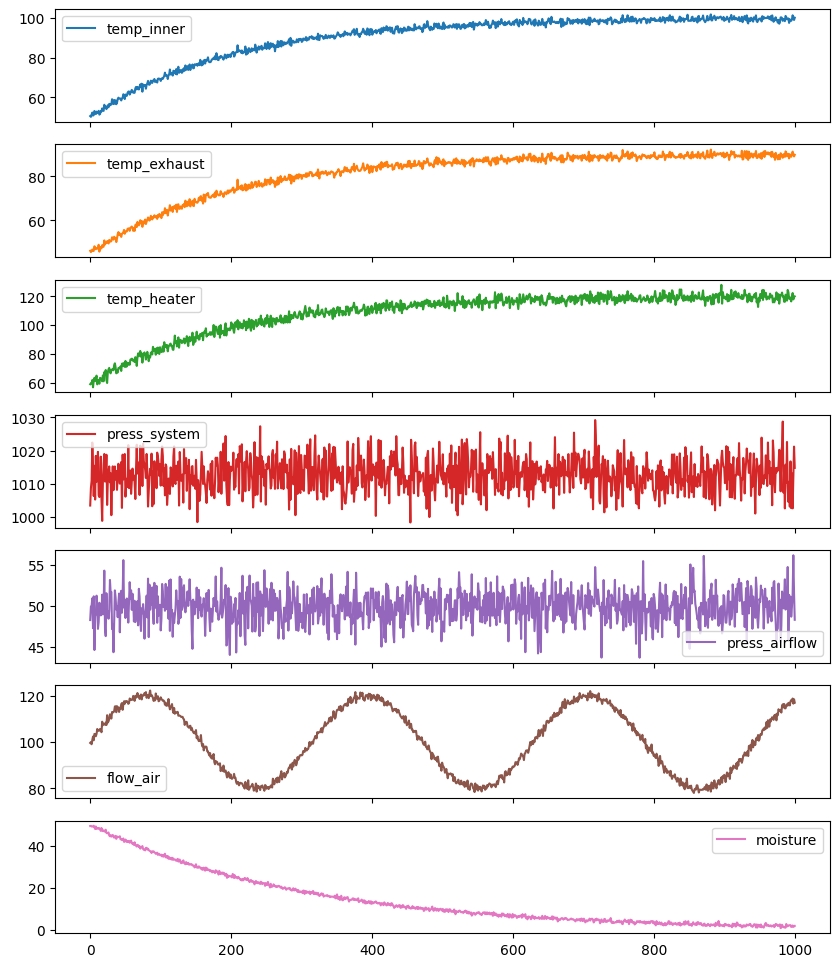

In [15]:
# ---------------------------------------------------
# 1. 샘플 데이터 생성
# ---------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

main_feature = 'press_system'
main_feature_col_num = 0
def generate_sample_data():
    # 1. 시뮬레이션 설정
    np.random.seed(42)
    n_steps = 1000 # 총 데이터 포인트 수
    time = np.arange(n_steps)

    # 2. 센서 데이터 생성 (물리적 특성 반영)
    # 내부 온도: 상승 후 일정 유지
    temp_inner = 50 + 50 * (1 - np.exp(-time/200)) + np.random.normal(0, 1, n_steps)
    # 배기 온도: 내부 온도보다 조금 낮게
    temp_exhaust = temp_inner * 0.9 + np.random.normal(0, 0.5, n_steps)
    # 가열기 온도: 내부 온도보다 높게
    temp_heater = temp_inner * 1.2 + np.random.normal(0, 2, n_steps)
    # 시스템 압력: 일정 범위 유지
    press_system = 1013 + np.random.normal(0, 5, n_steps)
    # 공기 흐름 압력: 일정 범위 유지
    press_airflow = 50 + np.random.normal(0, 2, n_steps)
    # 열풍 유량: 초기 상승 후 안정
    flow_air = 100 + 20 * np.sin(time/50) + np.random.normal(0, 1, n_steps)
    # 수분 함량: 점차 감소 (exponential decay)
    moisture = 50 * np.exp(-time/300) + np.random.normal(0, 0.5, n_steps)
    moisture = np.maximum(moisture, 0) # 0 이하 방지

    # 3. 데이터프레임 구성
    df = pd.DataFrame({
        'temp_inner': temp_inner,
        'temp_exhaust': temp_exhaust,
        'temp_heater': temp_heater,
        main_feature: press_system,
        'press_airflow': press_airflow,
        'flow_air': flow_air,
        'moisture': moisture
    })
    if main_feature in df.columns:
        main_feature_col_num = df.columns.get_loc(main_feature)
    return df


sample_data = generate_sample_data()
sample_data.plot(subplots=True, figsize=(10, 12))
plt.show()

In [ ]:
# ---------------------------------------------------
# 2. 데이터 정규화 #1 (0 ~ 1)
# -> 기본 선언
# ---------------------------------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(sample_data)
print(f"sample_data shape: {sample_data.shape}, {type(sample_data)}")
print(f"Scaled_data shape: {scaled_data.shape}, {type(scaled_data)}")
# 2. LSTM용 3D 데이터 구조로 변환 함수
def create_dataset(dataset, look_back=1, feature_columns=6):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), :] # 이전 X개 타임스텝
        X.append(a)
        Y.append(dataset[i + look_back, feature_columns]) # 다음 시점의 수분 함량 (Target)
    return np.array(X), np.array(Y)

# 3. 데이터셋 분할 및 구조화
look_back = 100 # 과거 100개 데이터를 기반으로 예측 (windows size)

X_100, y_100 = create_dataset(scaled_data, look_back, main_feature_col_num)
look_back = 10  # 과거 10개 데이터를 기반으로 예측
X_10, y_10 = create_dataset(scaled_data, look_back, main_feature_col_num)

X = X_100
y = y_100
# Train/Test 분할 (80/20)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"X_train shape: {X_train.shape}") # (samples, 100, 7)
print(f"y_train shape: {y_train.shape}") # (samples,)

sample_data shape: (1000, 7), <class 'pandas.DataFrame'>
Scaled_data shape: (1000, 7), <class 'numpy.ndarray'>
X_train shape: (791, 10, 7)
y_train shape: (791,)


In [ ]:
import tensorflow
print(tensorflow, tensorflow.__version__)

In [ ]:
# -------------------------------
# 5. Evaluate model
# -------------------------------
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

In [ ]:
# -------------------------------
# 6. Save model
# -------------------------------
model_path = "iris_rf_model.pkl"
joblib.dump(clf, model_path)

In [ ]:
# -------------------------------
# 7. Upload model to ClearML
# -------------------------------
output_model = task.upload_artifact(
    name="iris_rf_model",
    artifact_object=model_path
)
print(f"Model uploaded to ClearML: {output_model}")

In [ ]:
# -------------------------------
# 8. Close task
# -------------------------------
if task is not None:
    task.close()